# Kelmarsh: does real local wind speed beat PECD's weather input?

`12_kelmarsh_vs_pecd` found PECD's onshore wind capacity factor tracks
Kelmarsh's real metered generation well once corrected for measured
downtime -- but stayed noticeably noisy at native hourly resolution
(r=0.86 hourly vs. r=0.96 monthly). This page asks: is that hourly-scale
error mainly PECD's *weather input* (one large reanalysis grid cell
standing in for one specific farm) or its *wind-to-power conversion*?

Tested by swapping in something PECD doesn't have: Kelmarsh's own real,
per-turbine nacelle wind speed (`kelmarsh_turbine_scada` in this hub),
converted to power via `windpowerlib`'s real, published Senvion
MM92/2050 power curve -- an exact nameplate match for Kelmarsh's
turbines. Also checks two calibration questions along the way: does a
density-adjusted wind speed variant do any better, and how much of the
remaining gap is just unavoidable transformer/house-load loss rather
than modeling error. Prototyped in `energy-research`'s exploratory
pipeline (`04_compare_windspeed_reconstruction.py`) before being
rebuilt here against this hub's own outputs.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from windpowerlib import WindTurbine, power_output

from insights.paths import hub_file

PECD_ZONE = "UK03"

## Real generation + availability, and PECD (same as 12_kelmarsh_vs_pecd)

In [2]:
wt_static = pd.read_parquet(hub_file("kelmarsh", "kelmarsh_wt_static.parquet"))
installed_capacity_mw = wt_static["Rated power (kW)"].sum() / 1000

grid = pd.read_parquet(hub_file("kelmarsh", "kelmarsh_grid_meter.parquet"))
grid.index = grid.index.tz_localize("UTC")
actual_hourly_mw = (
    grid["Grid Meter Energy Export (kWh)"].resample("h").sum(min_count=6).div(1000).rename("actual")
)
hourly_availability = grid["Energy meter based availability"].resample("h").mean()

pecd_decades = ["2010-2019", "2020-2025"]
pecd_cf = pd.concat(
    [
        pd.read_parquet(
            hub_file("pecd", "capacity_factors_europe", f"pecd_wind_onshore_tech30_{label}.parquet"),
            columns=[PECD_ZONE],
        )[PECD_ZONE]
        for label in pecd_decades
    ]
).sort_index()
pecd_cf.index = pecd_cf.index.tz_localize("UTC")
pecd_raw_mw = (pecd_cf * installed_capacity_mw).rename("pecd_raw")

## Wind-speed reconstruction: real per-turbine wind speed -> MM92/2050 power curve

Each turbine's own 10-minute nacelle wind speed goes through
`windpowerlib`'s real MM92/2050 power curve directly -- no hub-height
extrapolation needed, the nacelle anemometer already measures at
(approximately) hub height. Summed across all 6 turbines, resampled to
hourly. `min_count=6` requires every turbine present before summing,
else the farm total is correctly `NaN` rather than silently understated
by a missing turbine.

In [3]:
scada = pd.read_parquet(hub_file("kelmarsh", "kelmarsh_turbine_scada.parquet"))

wt = WindTurbine(turbine_type="MM92/2050", hub_height=78.5)
power_curve = wt.power_curve


def farm_mw_from_wind_speed(column: str) -> pd.Series:
    wide = scada.pivot(index="timestamp", columns="turbine", values=column)
    wide.index = wide.index.tz_localize("UTC")
    modeled_w = wide.apply(
        lambda ws: power_output.power_curve(
            wind_speed=ws,
            power_curve_wind_speeds=power_curve["wind_speed"],
            power_curve_values=power_curve["value"],
        )
    )
    return (modeled_w.sum(axis=1, min_count=6) / 1_000_000).resample("h").mean()  # W -> MW


windspeed_raw_mw = farm_mw_from_wind_speed("Wind speed (m/s)").rename("windspeed_raw")

## Calibration check 1: sum of each turbine's own real metered Power (kW)

Not a model at all -- sums Kelmarsh's own per-turbine metered output
directly, no wind speed or power curve involved. Shows how much of any
wind-speed method's remaining gap is just normal transformer/house-load
loss between the turbines' own meters and the grid connection point,
rather than modeling error -- an upper bound on how close any
turbine-level reconstruction could plausibly get.

In [4]:
turbine_power_wide = scada.pivot(index="timestamp", columns="turbine", values="Power (kW)")
turbine_power_wide.index = turbine_power_wide.index.tz_localize("UTC")
turbine_power_sum_mw = (
    (turbine_power_wide.sum(axis=1, min_count=6) / 1000).resample("h").mean().rename("turbine_power_sum")
)

## Availability-adjust PECD and the wind-speed reconstruction

Same correction as `12_kelmarsh_vs_pecd`: scale by the hour's fraction
of 10-minute intervals flagged available. **Not** applied to
`turbine_power_sum` -- that's real measured output, downtime already
baked in correctly.

In [5]:
comparison = pd.concat(
    [actual_hourly_mw, pecd_raw_mw, windspeed_raw_mw, turbine_power_sum_mw, hourly_availability.rename("hourly_availability")],
    axis=1,
    sort=True,
)
valid_range = actual_hourly_mw.dropna()
comparison = comparison.loc[valid_range.index.min() : valid_range.index.max()]
comparison["pecd_adj"] = comparison["pecd_raw"] * comparison["hourly_availability"]
comparison["windspeed_adj"] = comparison["windspeed_raw"] * comparison["hourly_availability"]


def stats(actual: pd.Series, other: pd.Series) -> dict:
    joined = pd.concat([actual, other], axis=1).dropna()
    a, b = joined.iloc[:, 0], joined.iloc[:, 1]
    err = b - a
    return {"corr": a.corr(b), "mae_mw": err.abs().mean(), "nmae_pct": err.abs().mean() / a.mean() * 100, "bias_mw": err.mean()}


summary = pd.DataFrame(
    {col: stats(comparison["actual"], comparison[col]) for col in ["pecd_raw", "pecd_adj", "windspeed_raw", "windspeed_adj", "turbine_power_sum"]}
).T
print(summary.round(3))

                    corr  mae_mw  nmae_pct  bias_mw
pecd_raw           0.810   1.341    40.643   -0.100
pecd_adj           0.855   1.181    35.798   -0.260
windspeed_raw      0.955   0.363    10.846    0.022
windspeed_adj      0.992   0.246     7.330   -0.096
turbine_power_sum  0.968   0.134     4.006    0.109


## Calibration check 2: is density-adjusted wind speed actually better?

`Density adjusted wind speed (m/s)` should in principle line up more
accurately with a power curve (defined for a reference air density) --
but its ~8% missing rows turn out to concentrate almost exactly in
low-availability hours, not randomly.

In [6]:
is_missing = scada["Density adjusted wind speed (m/s)"].isna()
avail_when_present = scada.loc[~is_missing, "Data Availability"].mean()
avail_when_missing = scada.loc[is_missing, "Data Availability"].mean()
print(f"Mean Data Availability when density-adjusted wind speed is present: {avail_when_present:.3f}")
print(f"Mean Data Availability when density-adjusted wind speed is missing: {avail_when_missing:.3f}")

windspeed_densityadj_raw_mw = farm_mw_from_wind_speed("Density adjusted wind speed (m/s)")
windspeed_densityadj_adj_mw = windspeed_densityadj_raw_mw * hourly_availability.reindex(windspeed_densityadj_raw_mw.index)
adj_comparison = pd.concat(
    [comparison["actual"], comparison["windspeed_adj"], windspeed_densityadj_adj_mw.rename("windspeed_densityadj_adj")],
    axis=1,
    sort=True,
).dropna()
s_plain = stats(adj_comparison["actual"], adj_comparison["windspeed_adj"])
s_dens = stats(adj_comparison["actual"], adj_comparison["windspeed_densityadj_adj"])
print(f"\nAvailability-adjusted, both fairly compared on the same hours (n={len(adj_comparison):,}):")
print(f"  plain wind speed:            NMAE {s_plain['nmae_pct']:.2f}%")
print(f"  density-adjusted wind speed: NMAE {s_dens['nmae_pct']:.2f}%")

Mean Data Availability when density-adjusted wind speed is present: 1.000
Mean Data Availability when density-adjusted wind speed is missing: 0.671



Availability-adjusted, both fairly compared on the same hours (n=27,336):
  plain wind speed:            NMAE 7.10%
  density-adjusted wind speed: NMAE 7.33%


Confirmed: `Data Availability` averages ~1.00 when the density-adjusted
signal is present but only ~0.67 when it's missing -- the density-
adjusted column's missingness isn't random, it concentrates in
downtime. That means comparing it "raw" would look artificially good
(the hard hours are simply dropped, not well predicted). Compared
fairly on the same hours, plain and density-adjusted wind speed land
within a few hundredths of a percentage point of each other -- the
density correction adds nothing measurable here. Worth remembering
generally: check *why* two series disagree before crediting either one.

## Hourly scatter: PECD, wind-speed reconstruction, and the real-power ceiling

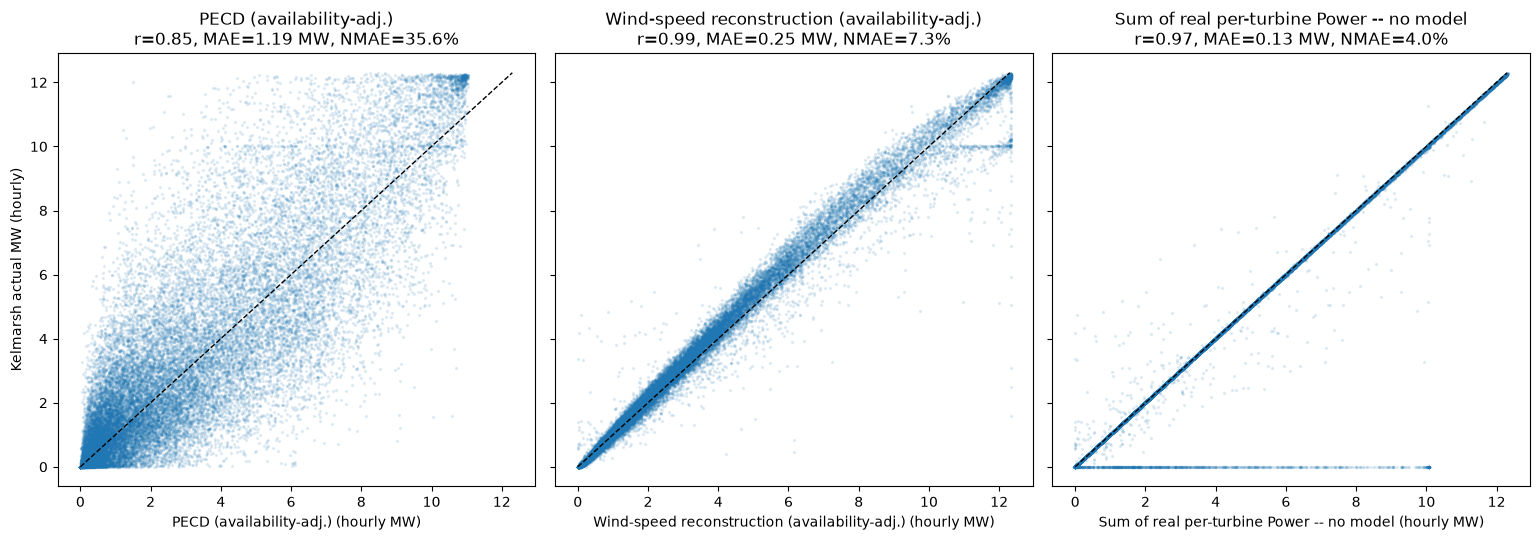

In [7]:
hourly = comparison[["actual", "pecd_adj", "windspeed_adj", "turbine_power_sum"]].dropna()

panels = [
    ("pecd_adj", "PECD (availability-adj.)"),
    ("windspeed_adj", "Wind-speed reconstruction (availability-adj.)"),
    ("turbine_power_sum", "Sum of real per-turbine Power -- no model"),
]
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.5), sharex=True, sharey=True)
for ax, (col, title) in zip(axes, panels):
    ax.scatter(hourly[col], hourly["actual"], s=2, alpha=0.1, rasterized=True)
    lims = [0, installed_capacity_mw]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel(f"{title} (hourly MW)")
    s = stats(hourly["actual"], hourly[col])
    ax.set_title(f"{title}\nr={s['corr']:.2f}, MAE={s['mae_mw']:.2f} MW, NMAE={s['nmae_pct']:.1f}%")
axes[0].set_ylabel("Kelmarsh actual MW (hourly)")
fig.tight_layout()
plt.show()

## Daily-mean overlay

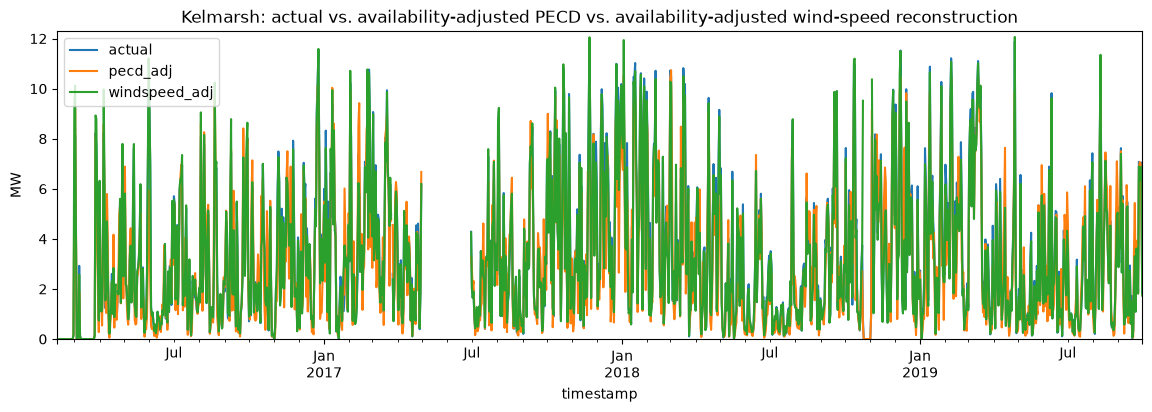

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
comparison[["actual", "pecd_adj", "windspeed_adj"]].resample("D").mean().plot(ax=ax)
ax.set_ylabel("MW")
ax.set_ylim(0, installed_capacity_mw)
ax.set_title("Kelmarsh: actual vs. availability-adjusted PECD vs. availability-adjusted wind-speed reconstruction")
plt.show()

## Takeaways

- Real per-turbine wind speed through a real MM92/2050 power curve,
  summed to farm level and availability-adjusted the same way as PECD,
  beats availability-adjusted PECD by a wide margin at hourly
  resolution: NMAE 7.3% vs. PECD's 35.8%, correlation 0.99 vs. 0.86.
- This points squarely at PECD's *weather input* as the main source of
  hourly-scale error, not its wind-to-power conversion approach -- a
  real, local, farm-specific wind measurement plus a comparably simple
  power-curve conversion already reconstructs generation far more
  closely than one large reanalysis grid cell can.
- **The density-adjusted wind speed variant was a methodology lesson,
  not a modeling win:** its apparently better "raw" score was a
  data-coverage artifact (missing rows concentrate in downtime hours),
  not genuinely better power-curve accuracy -- fairly compared, it adds
  nothing measurable over plain wind speed.
- **Real per-turbine power sets a real ceiling:** even summing
  Kelmarsh's own metered per-turbine output (no model at all) still
  misses the grid-meter reading by NMAE 4.0% -- ordinary transformer/
  house-load loss. Roughly half of the wind-speed reconstruction's 7.3%
  error is that same unavoidable physical gap, not modeling
  imprecision -- useful context for how much further any better
  conversion model could plausibly close things.
- Caveat: still not a fully controlled isolation of "PECD's conversion
  formula" alone -- PECD's own raw wind-speed field (not just its
  finished capacity-factor product) isn't in this hub, so the
  weather-input-vs-conversion-formula question is strongly suggested by
  elimination here, not cleanly separated.